# 03 — Envelopes, Loops & Zones

**Level:** Intermediate

A raw sample is rarely played “as-is”. Hardware and software samplers add:

1. **ADSR** — shape loudness over the note
2. **Loops** — sustain forever from a short buffer
3. **Zones** — different samples for pitch / velocity ranges (multisampling)

## Setup

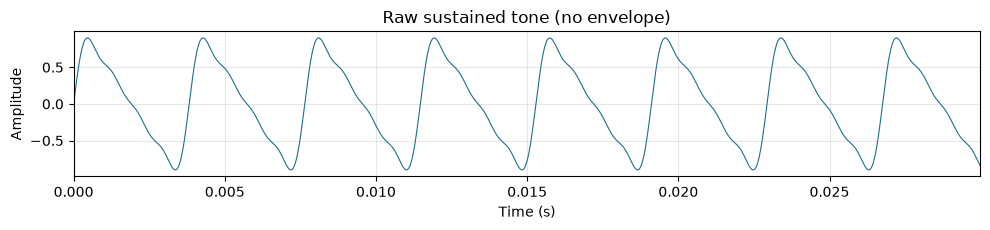

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from audio_utils import (
    SR, hear, normalize, seconds, midi_to_hz, semitone_ratio,
    linear_resample, apply_adsr, mix,
)

def make_tone(midi=60, dur=2.0, harm=(1, 0.4, 0.2, 0.1)):
    t = np.arange(seconds(dur)) / SR
    f = midi_to_hz(midi)
    y = sum(a * np.sin(2 * np.pi * f * (k + 1) * t) for k, a in enumerate(harm))
    return normalize(y)

raw = make_tone(60, dur=2.0)
hear(raw, SR, title="Raw sustained tone (no envelope)", max_waveform_seconds=0.03)

## ADSR amplitude envelope

Attack → Decay → Sustain level → Release. Same sample, four musical articulations.

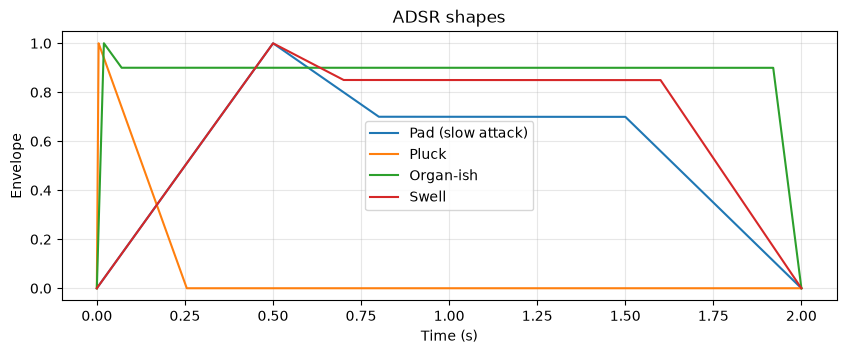

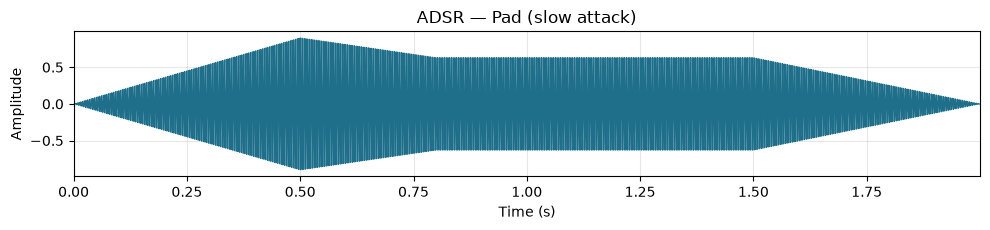

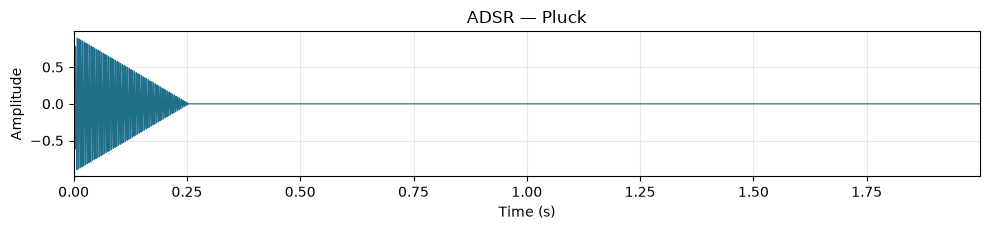

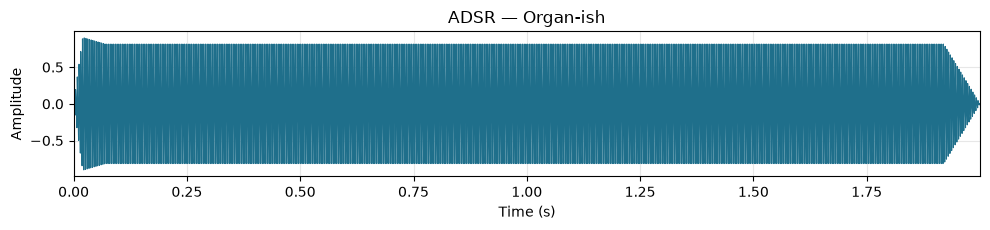

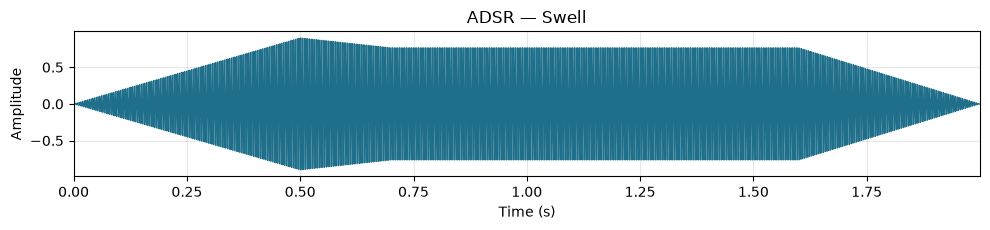

In [2]:
articulations = {
    "Pad (slow attack)": dict(attack=0.6, decay=0.3, sustain=0.7, release=0.5),
    "Pluck": dict(attack=0.005, decay=0.25, sustain=0.0, release=0.05),
    "Organ-ish": dict(attack=0.02, decay=0.05, sustain=0.9, release=0.08),
    "Swell": dict(attack=0.9, decay=0.2, sustain=0.85, release=0.4),
}

# Visualize envelopes alone
fig, ax = plt.subplots(figsize=(10, 3.5))
for name, params in articulations.items():
    dummy = np.ones(seconds(2.0))
    env = apply_adsr(dummy, **params)
    ax.plot(np.arange(len(env)) / SR, env, label=name)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Envelope")
ax.set_title("ADSR shapes")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

for name, params in articulations.items():
    shaped = apply_adsr(raw, **params)
    hear(shaped, SR, title=f"ADSR — {name}", max_waveform_seconds=None)

## Crossfade looping

Mark a loop region and crossfade the seam so a short vowel / pad cycle can sustain indefinitely without a click.

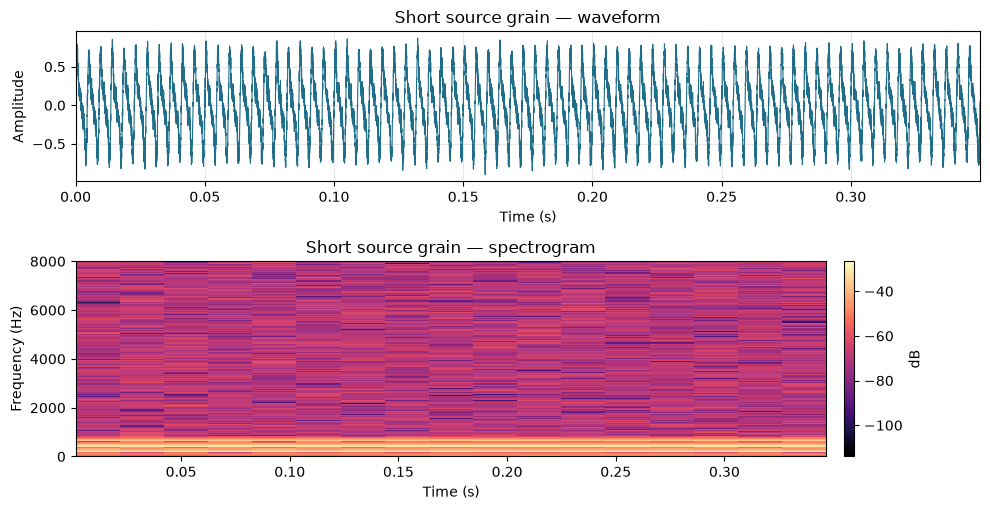

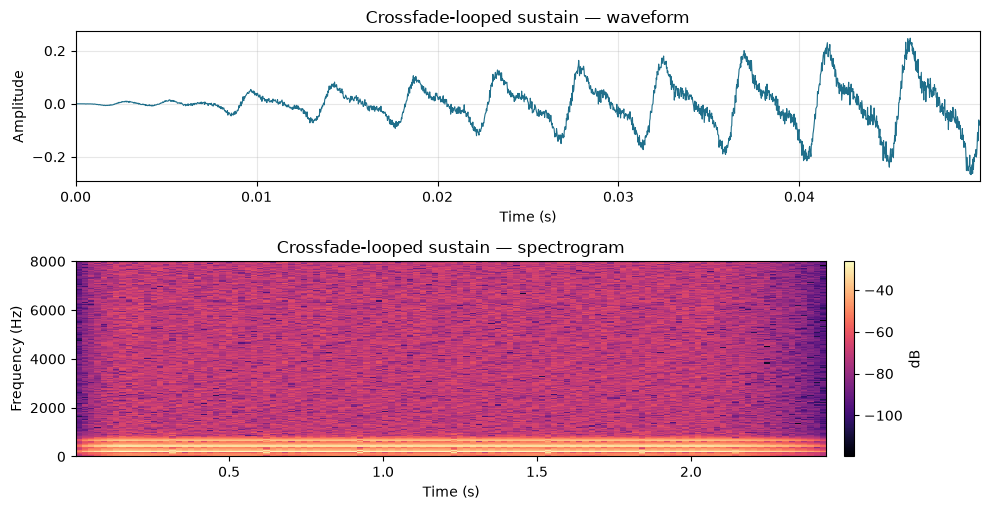

In [3]:
def crossfade_loop(x, loop_start, loop_end, fade):
    """Return one loop iteration with ends crossfaded (for tiling)."""
    x = np.asarray(x, dtype=np.float64).ravel()
    seg = x[loop_start:loop_end].copy()
    fade = min(fade, len(seg) // 3)
    if fade < 1:
        return seg
    fade_in = np.linspace(0, 1, fade)
    fade_out = 1 - fade_in
    # Blend end into start
    seg[:fade] = seg[:fade] * fade_in + seg[-fade:] * fade_out
    return seg[:-fade]  # drop the duplicated tail

# Build a breath-y vowel-ish grain and loop it
t = np.arange(seconds(0.35)) / SR
vowel = (
    0.6 * np.sin(2 * np.pi * 220 * t)
    + 0.35 * np.sin(2 * np.pi * 440 * t)
    + 0.2 * np.sin(2 * np.pi * 660 * t)
    + 0.08 * np.random.default_rng(1).normal(0, 1, len(t))
)
vowel = normalize(vowel)

loop_body = crossfade_loop(vowel, loop_start=1000, loop_end=len(vowel) - 500, fade=400)
sustained = np.tile(loop_body, 8)
sustained = apply_adsr(sustained, attack=0.15, decay=0.1, sustain=0.85, release=0.4)

hear(vowel, SR, title="Short source grain", show_spec=True)
hear(sustained, SR, title="Crossfade-looped sustain", show_spec=True, max_waveform_seconds=0.05)

## Velocity layers

Harder hits → brighter / louder samples. We fake two layers (soft sine-rich vs. bright) and switch by velocity.

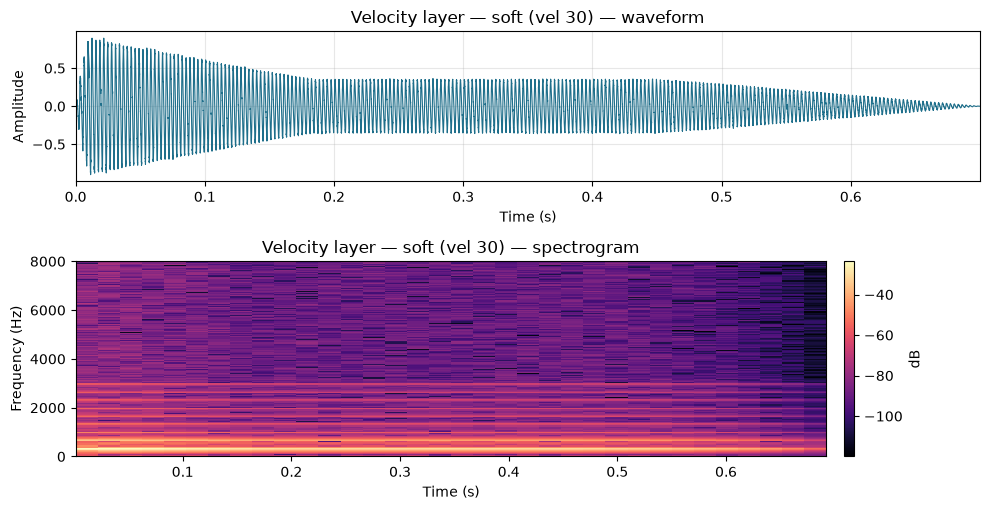

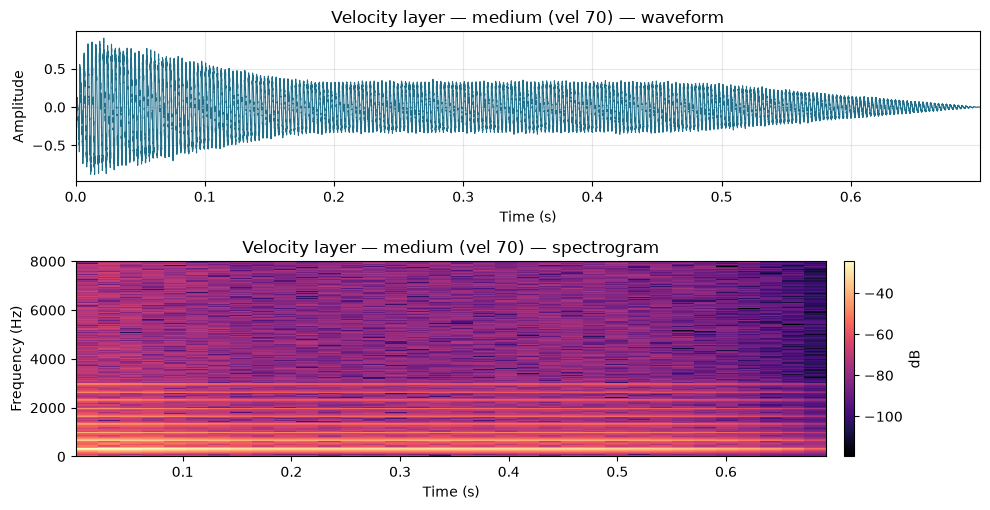

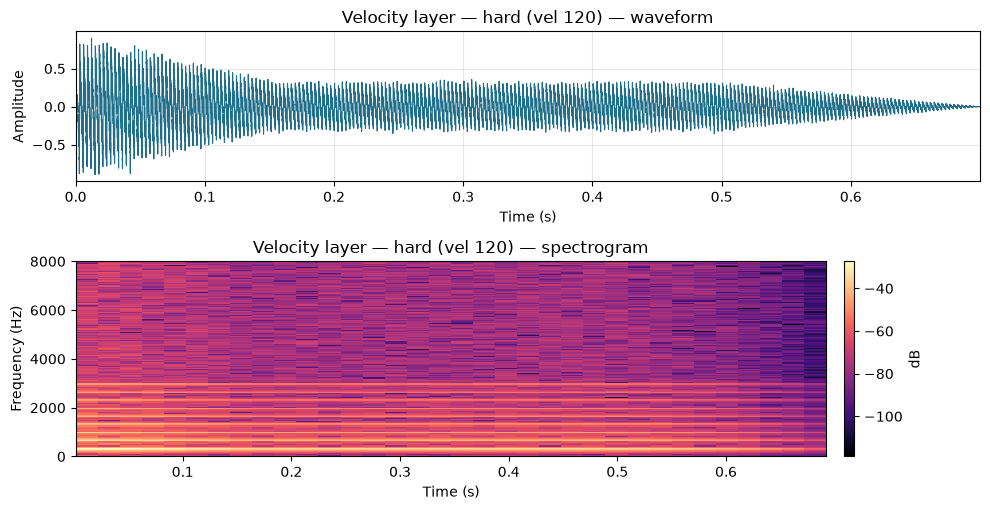

In [4]:
def soft_layer(midi, dur=0.7):
    t = np.arange(seconds(dur)) / SR
    f = midi_to_hz(midi)
    y = 0.7 * np.sin(2 * np.pi * f * t) + 0.15 * np.sin(2 * np.pi * 2 * f * t)
    return apply_adsr(normalize(y), attack=0.01, decay=0.2, sustain=0.4, release=0.25)

def hard_layer(midi, dur=0.7):
    t = np.arange(seconds(dur)) / SR
    f = midi_to_hz(midi)
    y = sum((1 / k) * np.sin(2 * np.pi * f * k * t) for k in range(1, 10))
    y += 0.15 * np.random.default_rng(midi).normal(0, 1, len(t))
    return apply_adsr(normalize(y), attack=0.003, decay=0.15, sustain=0.35, release=0.2)

def velocity_sample(midi, velocity):
    # velocity 0..127
    soft = soft_layer(midi)
    hard = hard_layer(midi)
    mix_amt = np.clip(velocity / 127, 0, 1)
    return normalize((1 - mix_amt) * soft + mix_amt * hard) * (0.4 + 0.6 * mix_amt)

for vel, name in [(30, "soft (vel 30)"), (70, "medium (vel 70)"), (120, "hard (vel 120)")]:
    hear(velocity_sample(64, vel), SR, title=f"Velocity layer — {name}", show_spec=True)

## Key zones (multisample map)

Split the keyboard: low zone uses a low root sample, high zone uses a high root. Less extreme stretching → more natural tone.

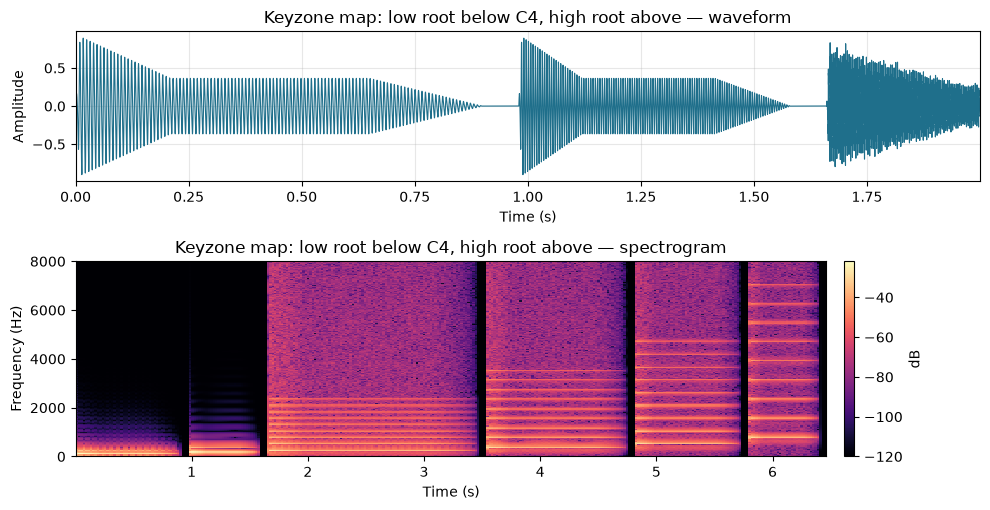

In [5]:
low_root = soft_layer(48, dur=0.9)   # C3 sample
high_root = hard_layer(72, dur=0.9)  # C5 sample

def zoned_note(note_midi):
    if note_midi < 60:
        return linear_resample(low_root, semitone_ratio(note_midi - 48))
    return linear_resample(high_root, semitone_ratio(note_midi - 72))

notes = [48, 55, 60, 67, 72, 79]
parts = []
for n in notes:
    parts.append(zoned_note(n))
    parts.append(np.zeros(seconds(0.08)))
phrase = normalize(np.concatenate(parts))
hear(phrase, SR, title="Keyzone map: low root below C4, high root above", show_spec=True)

## You should be able to…

- Shape the same buffer with different ADSRs
- Build a click-free crossfade loop
- Explain why velocity layers and keyzones beat extreme stretching

**Next:** [04 — Filters, FX & modulation](04_filters_fx_and_modulation.ipynb)